## Reinforcement Learning

In [62]:
import os
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix

# Define a label-to-integer mapping
label_to_int = {"Breathy": 0, "Normal": 1, "Pressed": 2, "Flow": 3}
int_to_label = {v: k for k, v in label_to_int.items()}

class ClassificationEnv(gym.Env):
    def __init__(self, X, y):
        super(ClassificationEnv, self).__init__()
        self.X = X
        # Map y labels to integers using the label_to_int dictionary
        self.y = np.array([label_to_int[label] for label in y])
        self.current_idx = 0
        
        # Define action and observation spaces
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(X.shape[1],), dtype=np.float32)
        self.action_space = spaces.Discrete(len(label_to_int))  # One action per class label

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)  # Handle seeding
        self.current_idx = np.random.randint(0, len(self.X))  # Start at a random sample
        return self.X[self.current_idx], {}  # Gymnasium reset now returns observation and info dict

    def step(self, action):
        correct_label = self.y[self.current_idx]
        reward = 1 if action == correct_label else -1  # Reward based on correct classification
        done = True  # End episode after each prediction
        info = {}
        self.current_idx = np.random.randint(0, len(self.X))  # Move to next sample for next reset
        return self.X[self.current_idx], reward, done, False, info  # Gymnasium step returns 5 values

def ppo_classification(model_name, k=5, n_steps=10000):
    # Create a DataFrame to store results
    results_df = pd.DataFrame({'Layer': [], 'Fold': [], 'Fold_Accuracy': []})
    confusion_matrices = []

    # Specify the folder path and model name
    folder_path_base = "embeddings/" + model_name + "/"

    # Get the list of layer folders
    layer_folders = sorted([int(folder) for folder in os.listdir(folder_path_base) if os.path.isdir(os.path.join(folder_path_base, folder))])

    # Iterate over the layer folders
    for layer_num in tqdm(layer_folders, desc="Layer-wise classification"):
        # Specify the folder path for the current layer
        folder_path = os.path.join(folder_path_base, str(layer_num))

        # Load X and y from the corresponding files
        X = np.load(os.path.join(folder_path, "X.npy"), allow_pickle=True)
        y = np.load(os.path.join(folder_path, "y.npy"), allow_pickle=True)

        # Initialize StratifiedKFold
        skf = StratifiedKFold(n_splits=k)

        # Store cross-validation results
        for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]

            # Create the training environment with the training set
            train_env = ClassificationEnv(X_train, y_train)
            test_env = ClassificationEnv(X_test, y_test)

            # Initialize PPO model
            model = PPO("MlpPolicy", train_env, verbose=0)
            model.learn(total_timesteps=n_steps)  # Train PPO for a set number of steps

            # Evaluate model on test set
            correct_preds = 0
            y_pred_all, y_true_all = [], []

            for i in range(len(X_test)):
                obs, _ = test_env.reset()
                action, _ = model.predict(obs, deterministic=True)
                correct_label = label_to_int[y_test[i]]  # Convert correct_label to integer
                y_pred_all.append(action)
                y_true_all.append(correct_label)
                if action == correct_label:
                    correct_preds += 1

            # Calculate accuracy
            accuracy = correct_preds / len(X_test)
            
            # Store fold results
            fold_results_df = pd.DataFrame({
                'Layer': [layer_num],
                'Fold': [fold_num],
                'Fold_Accuracy': [accuracy]
            }, index=[0])
            results_df = pd.concat([results_df, fold_results_df], ignore_index=True)

            # Generate confusion matrix
            cm = confusion_matrix(y_true_all, y_pred_all)
            confusion_matrices.append((layer_num, fold_num, cm))

    return results_df, confusion_matrices

In [64]:
results_df, confusion_matrices = ppo_classification("hubert", k=5, n_steps=10000)

Layer-wise classification: 100%|████████████████| 25/25 [31:12<00:00, 74.90s/it]


In [69]:
results_df

,Layer,Fold,Fold_Accuracy
0,0.0,0.0,0.202614
1,0.0,1.0,0.281046
2,0.0,2.0,0.250000
3,0.0,3.0,0.276316
4,0.0,4.0,0.210526
...,...,...,...
120,24.0,0.0,0.254902
121,24.0,1.0,0.261438
122,24.0,2.0,0.203947
123,24.0,3.0,0.276316


In [67]:
results_df["Fold_Accuracy"].mean()

0.2698637770897834

In [68]:
results_df["Fold_Accuracy"].max()

0.39215686274509803

/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


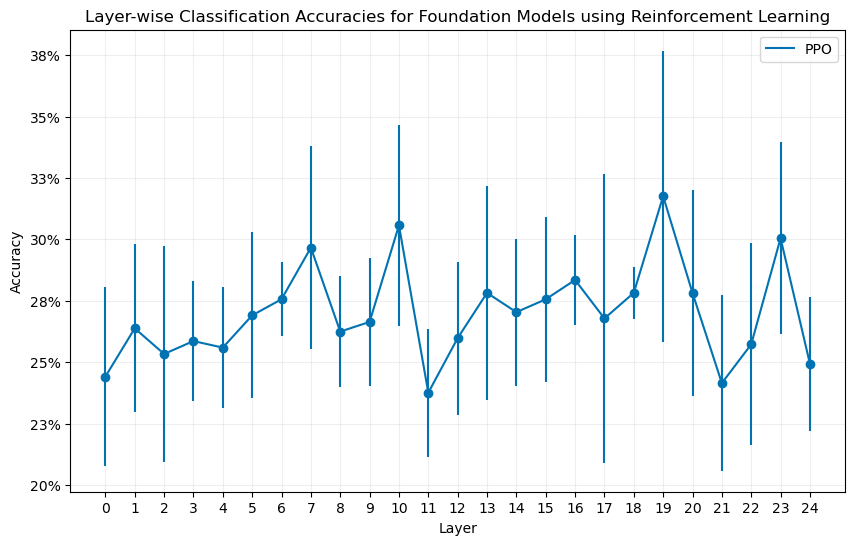

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Calculate mean and standard deviation for each model
rl_mean_accuracy = results_df.groupby('Layer')['Fold_Accuracy'].mean()
rl_std_accuracy = results_df.groupby('Layer')['Fold_Accuracy'].std()

# Combine dataframes
data = pd.concat([
    pd.DataFrame({'Layer': rl_mean_accuracy.index, 'Mean Accuracy': rl_mean_accuracy, 'Standard Deviation': rl_std_accuracy, 'Model': 'PPO'})
])

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=data, x='Layer', y='Mean Accuracy', hue='Model', marker='o', err_style='bars', errorbar='sd', palette='colorblind')

# Convert y-axis to percentages
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
# Show every value on the x-axis
plt.xticks(data['Layer'])

# Add error bars
for i, model in enumerate(['PPO']):
    model_data = data[data['Model'] == model]
    plt.errorbar(model_data['Layer'], model_data['Mean Accuracy'], yerr=model_data['Standard Deviation'], fmt='o', color=sns.color_palette('colorblind')[i])

# Add labels and title
plt.xlabel('Layer')
plt.ylabel('Accuracy')
plt.title('Layer-wise Classification Accuracies for Foundation Models using Reinforcement Learning')

# Show plot
plt.legend()
plt.grid(True, alpha=0.2)

plt.show()

## Classification based on wav2vec2processor

In [58]:
from wav_to_embedding import get_wav_files, wav2input, wav_to_embedding
import os
import tqdm
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV

import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models

def generate_embeddings(data_directory, model_name):

    wav_files = get_wav_files(data_directory)

    embeddings = []
    for file_path, label in tqdm.tqdm(wav_files, desc="Processing WAV files"):
        # Obtain the embedding for the current WAV file
        input_tensors = wav2input(file_path, model_name)
        print(input_tensors.shape)
        embedding = input_tensors.detach().numpy()[0]
        embeddings.append((file_path, label, embedding))

    # Convert the data list to a DataFrame
    embeddings_df = pd.DataFrame(embeddings, columns=['Soundtrack', 'Label', 'InputEmbedding'])

    # Extract embeddings for the current layer
    max_length = max(len(embedding) for embedding in embeddings_df['InputEmbedding'])
    X = np.array(embeddings_df['InputEmbedding'])
    y = embeddings_df['Label']

    # Specify the folder path
    folder_path = "input_embeddings/"+model_name+"/"

    # Create the folder if it doesn't exist
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    # Save the array in the specified folder
    np.save(folder_path + "X.npy", X)
    np.save(folder_path + "y.npy", y)

def classify_phonation_mode(model_name):

    # Create a DataFrame to store results
    results_df = pd.DataFrame({'Actual_Label': [], 'Predicted_Label': [], 'Layer': [], 'Layer_Accuracy': []})

    # Specify the folder path and model name
    folder_path = "input_embeddings/" + model_name + "/"

    # Load X and y from the corresponding files
    X = np.load(os.path.join(folder_path, "X.npy"), allow_pickle=True)
    y = np.load(os.path.join(folder_path, "y.npy"), allow_pickle=True)

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train SVM classifier
    svm_classifier = SVC(kernel='linear')  # Linear kernel works well for high-dimensional data
    svm_classifier.fit(X_train, y_train)

    # Evaluate classifier
    y_pred = svm_classifier.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    # print(f"Accuracy for Layer {layer_num}: {accuracy}")

    # Create a DataFrame to store results for the current layer
    layer_results_df = pd.DataFrame({
        'Actual_Label': y_test,
        'Predicted_Label': y_pred,
        'Layer': layer_num,
        'Layer_Accuracy': accuracy
    })
    
    # Concatenate the results with the overall results_df
    results_df = pd.concat([results_df, layer_results_df], ignore_index=True)

    return results_df

In [59]:
generate_embeddings("data", "hubert")

Processing WAV files:  12%|██▎                | 95/762 [00:00<00:01, 476.70it/s]

torch.Size([1, 19153])
torch.Size([1, 23535])
torch.Size([1, 18356])
torch.Size([1, 14056])
torch.Size([1, 17874])
torch.Size([1, 18144])
torch.Size([1, 19439])
torch.Size([1, 21429])
torch.Size([1, 17869])
torch.Size([1, 20697])
torch.Size([1, 19258])
torch.Size([1, 17395])
torch.Size([1, 16878])
torch.Size([1, 17056])
torch.Size([1, 20712])
torch.Size([1, 19835])
torch.Size([1, 17666])
torch.Size([1, 18492])
torch.Size([1, 19258])
torch.Size([1, 17774])
torch.Size([1, 18851])
torch.Size([1, 19024])
torch.Size([1, 18186])
torch.Size([1, 21008])
torch.Size([1, 22484])
torch.Size([1, 19877])
torch.Size([1, 18945])
torch.Size([1, 19370])
torch.Size([1, 18997])
torch.Size([1, 19556])
torch.Size([1, 18133])
torch.Size([1, 16245])
torch.Size([1, 19181])
torch.Size([1, 18790])
torch.Size([1, 19290])
torch.Size([1, 17415])
torch.Size([1, 19015])
torch.Size([1, 16378])
torch.Size([1, 14861])
torch.Size([1, 17778])
torch.Size([1, 20103])
torch.Size([1, 19783])
torch.Size([1, 19480])
torch.Size(

Processing WAV files:  26%|████▋             | 200/762 [00:00<00:01, 496.43it/s]

torch.Size([1, 20593])
torch.Size([1, 18601])
torch.Size([1, 17682])
torch.Size([1, 21434])
torch.Size([1, 19745])
torch.Size([1, 21434])
torch.Size([1, 21854])
torch.Size([1, 22484])
torch.Size([1, 21582])
torch.Size([1, 19117])
torch.Size([1, 21087])
torch.Size([1, 23222])
torch.Size([1, 16878])
torch.Size([1, 20259])
torch.Size([1, 18741])
torch.Size([1, 23265])
torch.Size([1, 19900])
torch.Size([1, 19569])
torch.Size([1, 20833])
torch.Size([1, 18501])
torch.Size([1, 18270])
torch.Size([1, 15379])
torch.Size([1, 16730])
torch.Size([1, 16622])
torch.Size([1, 19087])
torch.Size([1, 20483])
torch.Size([1, 14650])
torch.Size([1, 22167])
torch.Size([1, 19900])
torch.Size([1, 18482])
torch.Size([1, 18800])
torch.Size([1, 17765])
torch.Size([1, 12398])
torch.Size([1, 19459])
torch.Size([1, 21429])
torch.Size([1, 20136])
torch.Size([1, 18997])
torch.Size([1, 21123])
torch.Size([1, 18455])
torch.Size([1, 17235])
torch.Size([1, 19148])
torch.Size([1, 17949])
torch.Size([1, 18304])
torch.Size(

Processing WAV files:  41%|███████▍          | 314/762 [00:00<00:00, 535.33it/s]

...

torch.Size([1, 21089])
torch.Size([1, 22637])
torch.Size([1, 19480])
torch.Size([1, 22262])
torch.Size([1, 22945])
torch.Size([1, 22226])
torch.Size([1, 20825])
torch.Size([1, 29762])
torch.Size([1, 18835])
torch.Size([1, 24807])
torch.Size([1, 28536])
torch.Size([1, 20339])
torch.Size([1, 23159])
torch.Size([1, 27468])
torch.Size([1, 22234])
torch.Size([1, 23544])
torch.Size([1, 22009])
torch.Size([1, 24538])
torch.Size([1, 23021])
torch.Size([1, 24037])
torch.Size([1, 18478])
torch.Size([1, 22959])
torch.Size([1, 25636])
torch.Size([1, 21087])
torch.Size([1, 23849])
torch.Size([1, 22562])
torch.Size([1, 25150])
torch.Size([1, 23758])
torch.Size([1, 26351])
torch.Size([1, 25035])
torch.Size([1, 19900])
torch.Size([1, 21474])
torch.Size([1, 21356])
torch.Size([1, 22742])
torch.Size([1, 21528])
torch.Size([1, 24571])
torch.Size([1, 26740])
torch.Size([1, 23989])
torch.Size([1, 23421])
torch.Size([1, 21247])
torch.Size([1, 21389])
torch.Size([1, 19158])
torch.Size([1, 23955])
torch.Size(

Processing WAV files:  91%|████████████████▍ | 697/762 [00:01<00:00, 516.09it/s]

torch.Size([1, 21668])
torch.Size([1, 20736])
torch.Size([1, 25275])
torch.Size([1, 22342])
torch.Size([1, 21356])
torch.Size([1, 23019])
torch.Size([1, 22979])
torch.Size([1, 23418])
torch.Size([1, 30890])
torch.Size([1, 30987])
torch.Size([1, 24147])
torch.Size([1, 25043])
torch.Size([1, 20314])
torch.Size([1, 25317])
torch.Size([1, 24164])
torch.Size([1, 22262])
torch.Size([1, 22082])
torch.Size([1, 24169])
torch.Size([1, 21095])
torch.Size([1, 22248])
torch.Size([1, 28361])
torch.Size([1, 24346])
torch.Size([1, 23665])
torch.Size([1, 26600])
torch.Size([1, 18186])
torch.Size([1, 22000])
torch.Size([1, 26267])
torch.Size([1, 25436])
torch.Size([1, 17329])
torch.Size([1, 19569])
torch.Size([1, 21861])
torch.Size([1, 21644])
torch.Size([1, 24852])
torch.Size([1, 21723])
torch.Size([1, 21723])
torch.Size([1, 19965])
torch.Size([1, 26687])
torch.Size([1, 23343])
torch.Size([1, 24057])
torch.Size([1, 25114])
torch.Size([1, 26561])
torch.Size([1, 29236])
torch.Size([1, 21660])
torch.Size(

Processing WAV files: 100%|██████████████████| 762/762 [00:01<00:00, 518.02it/s]

torch.Size([1, 23284])
torch.Size([1, 23155])
torch.Size([1, 26570])
torch.Size([1, 24792])
torch.Size([1, 23629])
torch.Size([1, 24444])
torch.Size([1, 21723])
torch.Size([1, 24028])
torch.Size([1, 23149])
torch.Size([1, 21474])
torch.Size([1, 21873])
torch.Size([1, 22562])
torch.Size([1, 25720])
torch.Size([1, 23265])
torch.Size([1, 26174])
torch.Size([1, 23148])
torch.Size([1, 32212])
torch.Size([1, 24874])
torch.Size([1, 29537])
torch.Size([1, 19106])
torch.Size([1, 22925])
torch.Size([1, 21593])
torch.Size([1, 20045])
torch.Size([1, 22000])
torch.Size([1, 23991])


In [57]:
df = classify_phonation_mode("hubert")

ValueError: setting an array element with a sequence.

## Active Learning with SVM

In [76]:
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

In [77]:
# Specify the folder path and model name
model_name = "hubert"
folder_path_base = "embeddings/" + model_name + "/"
layer_num = 5
# Specify the folder path for the current layer
folder_path = os.path.join(folder_path_base, str(layer_num ))

# Load X and y from the corresponding files
X = np.load(os.path.join(folder_path, "X.npy"), allow_pickle=True)
y = np.load(os.path.join(folder_path, "y.npy"), allow_pickle=True)

In [78]:
human_proxy_svm = SVC(kernel='linear')  # Linear kernel works well for high-dimensional data
human_proxy_svm.fit(X, y)

SVC(kernel='linear')

In [97]:
# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=5)

# List to collect comparison results
comparison_data = []

# Store cross-validation results
for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Initialize the SVM with probability estimates
    base_svm = SVC(kernel='linear')
    svm = CalibratedClassifierCV(base_svm, method='sigmoid')  # Calibrate for probability output

    # Active learning parameters
    num_iterations = 10
    samples_per_iteration = 5
    
    for iteration in range(num_iterations):
        # Train the model
        svm.fit(X_train, y_train)
    
        # Get probability estimates for the test (unlabeled) data
        probabilities = svm.predict_proba(X_test)
        
        # Calculate uncertainty as the confidence (lowest probability of any class)
        uncertainties = 1 - np.max(probabilities, axis=1)
        
        # Find the most uncertain samples (highest uncertainty values)
        uncertain_indices = np.argsort(uncertainties)[-samples_per_iteration:]
        uncertain_samples = X_test[uncertain_indices]
        actual_labels = y_test[uncertain_indices]  # Retrieve actual labels from y_test
        
        # Model prediction on uncertain samples before getting human labels
        model_predictions = svm.predict(uncertain_samples)
        
        # Human annotates uncertain samples
        new_labels = human_proxy_svm.predict(uncertain_samples)  # Function to simulate human labels

        # Store comparison data
        for i, idx in enumerate(uncertain_indices):
            comparison_data.append({
                "Fold": fold_num,
                "Iteration": iteration,
                "Sample Index": idx,
                "Model Prediction": model_predictions[i],
                "Human Label (proxy)": new_labels[i],
                "Actual Label": actual_labels[i],
                "Uncertainity": f"{uncertainties.min()*100:.2f}%",
                # "Match": model_predictions[i] == new_labels[i]
            })

# Create a DataFrame from the collected data
comparison_df = pd.DataFrame(comparison_data)

# Save the comparison DataFrame to a CSV file
comparison_df.to_csv("results/active_learning_comparison_results.csv", index=False)

In [98]:
comparison_df

,Fold,Iteration,Sample Index,Model Prediction,Human Label (proxy),Actual Label,Uncertainity
0,0,0,125,Pressed,Flow,Flow,1.95%
1,0,0,25,Pressed,Pressed,Pressed,1.95%
2,0,0,144,Pressed,Flow,Flow,1.95%
3,0,0,137,Flow,Flow,Flow,1.95%
4,0,0,119,Pressed,Normal,Normal,1.95%
...,...,...,...,...,...,...,...
245,4,9,123,Flow,Flow,Flow,2.79%
246,4,9,146,Flow,Flow,Flow,2.79%
247,4,9,96,Normal,Normal,Normal,2.79%
248,4,9,54,Pressed,Pressed,Pressed,2.79%
